# 02 - Modelisation Random Forest

Ce notebook construit un modele de regression pour predire le salaire a partir des competences et du contexte du poste.

Plan:
1. Preparation des donnees
2. Feature engineering (skills + variables metier)
3. Entrainement du Random Forest
4. Evaluation des performances
5. Interpretation des variables importantes
6. Export du dataset encode

In [5]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import joblib

In [6]:
df = pd.read_csv('dataset_propre.csv')

## Etape 1 - Chargement et extraction des competences

On charge le dataset propre, puis on extrait les skills les plus frequentes pour construire les variables explicatives.

In [7]:
# Parsing robuste des skills (evite les problemes d'espaces et de matching partiel)
df['skills_clean'] = df['skills'].fillna('').str.lower().str.split(',')
df['skills_clean'] = df['skills_clean'].apply(lambda lst: [s.strip() for s in lst if s.strip()])
skills_list = df['skills_clean'].explode()
print(skills_list.nunique())

27592


In [8]:
top_50_skills = skills_list.value_counts().head(50).index.tolist()
print(len(top_50_skills))
print(top_50_skills[:10])

50
['python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++']


In [9]:
for skill in top_50_skills:
    # Match exact sur la liste nettoyee des skills
    df[skill] = df['skills_clean'].apply(lambda skills: 1 if skill in skills else 0)

print(df.shape)

(10197, 58)


In [10]:
def categorize_job(title):
    title = title.lower()
    if 'data scientist' in title:
        return 'data scientist'
    elif 'machine learning' in title or 'ml' in title:
        return 'ml engineer'
    elif 'data analyst' in title:
        return 'data analyst'
    elif 'data engineer' in title:
        return 'data engineer'
    elif 'software' in title:
        return 'software engineer'
    else:
        return 'other'

df['job_category'] = df['job_title'].apply(categorize_job)
print(df['job_category'].value_counts())

job_category
software engineer    9192
data scientist        856
ml engineer           116
data engineer          29
data analyst            4
Name: count, dtype: int64


## Etape 2 - Encodage et construction de la matrice X

On encode les variables categorielles (`seniority_level`, `job_category`) et on prepare `X` (features) et `y` (salaire cible).

In [11]:
le = LabelEncoder()
# Label Encoding pour seniority (il y a un ordre)
df['seniority_encoded'] = le.fit_transform(df['seniority_level'])

# One Hot Encoding pour job_category (pas d'ordre)
df = pd.get_dummies(df, columns=['job_category'],drop_first=True)

print(df.shape)

(10197, 63)


In [12]:
X = df.drop(columns=['skills', 'skills_clean', 'job_title', 'seniority_level',
                      'company', 'location', 'post_date', 'salary'])
y = df['salary'].astype(float)

print(X.shape)
print(X.dtypes.value_counts())

(10197, 55)
int64    51
bool      4
Name: count, dtype: int64


In [13]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f'Train : {X_train.shape}')
print(f'Test : {X_test.shape}')

Train : (8157, 55)
Test : (2040, 55)


In [14]:
model = RandomForestRegressor(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

print('Modele entraine avec succes !')

Modele entraine avec succes !


## Etape 3 - Entrainement et evaluation du modele

On entraine le Random Forest puis on evalue la performance avec MAE, RMSE, R2 et validation croisee.

In [15]:
print(X.dtypes[X.dtypes == 'object'])
print(X.dtypes.value_counts())
print()
print(X.columns.tolist())

Series([], dtype: object)
int64    51
bool      4
Name: count, dtype: int64

['python', 'java', 'javascript', 'aws', 'sql', 'agile', 'git', 'c#', 'software engineering', 'c++', 'kubernetes', 'docker', 'react', 'typescript', 'software development', 'linux', 'angular', 'go', 'html', 'css', 'azure', 'unit testing', 'jira', 'microservices', 'scrum', 'devops', 'node.js', 'cloud computing', '.net', 'jenkins', 'ci/cd', 'communication', 'computer science', 'c', 'agile development', 'machine learning', 'postgresql', 'gcp', 'nosql', 'mysql', 'confluence', 'distributed systems', 'sql server', 'continuous integration', 'software design', 'rest', "'machine learning'", 'terraform', 'kafka', 'data structures', 'seniority_encoded', 'job_category_data engineer', 'job_category_data scientist', 'job_category_ml engineer', 'job_category_software engineer']


In [16]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

# Validation croisee allegée avec melange
cv_model = RandomForestRegressor(n_estimators=120, random_state=42, n_jobs=-1)
kf = KFold(n_splits=3, shuffle=True, random_state=42)
cv_scores = cross_val_score(cv_model, X, y, cv=kf, scoring='r2', n_jobs=-1)

print(f'MAE  : ${mae:,.0f}')
print(f'RMSE : ${rmse:,.0f}')
print(f'R2 test : {r2:.3f}')
print(f'R2 CV (moyenne ± ecart-type) : {cv_scores.mean():.3f} ± {cv_scores.std():.3f}')

MAE  : $41,068
RMSE : $49,287
R2 test : 0.440
R2 CV (moyenne ± ecart-type) : 0.416 ± 0.020


In [17]:
print(df.groupby('seniority_level')['salary'].std())

seniority_level
Associate     50316.643608
Mid senior    47384.203936
junior        58661.635825
lead          74425.552130
midlevel      60335.335691
senior        62487.366804
Name: salary, dtype: float64


## Interpretation des performances

Le score R2 reste realiste pour un probleme de prediction salariale, car ces donnees sont heterogenes et bruitees.

A retenir:
- MAE: erreur moyenne en dollars
- RMSE: penalise davantage les grosses erreurs
- R2 test: performance sur le jeu de test
- R2 CV: stabilite du modele sur plusieurs sous-ensembles

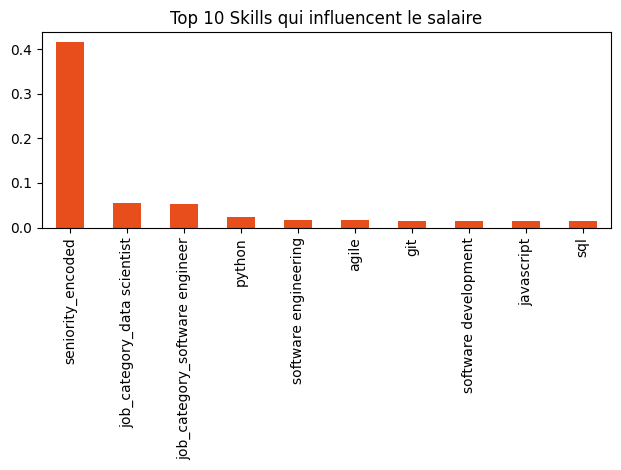

In [18]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(10).plot(kind='bar', color='#e84e1b')
plt.title('Top 10 Skills qui influencent le salaire')
plt.tight_layout()
plt.show()

## Conclusion

Ce notebook montre que:
- le modele Random Forest capture des patterns utiles entre skills, contexte et salaire
- le niveau d'experience influence fortement la prediction
- l'evaluation est plus fiable avec MAE + RMSE + R2 test + validation croisee

Livrables:
- un modele baseline solide et interpretable
- dataset_encode.csv pret pour tuning avance et deploiement

In [19]:
df.to_csv('dataset_encode.csv', index=False)
print('✅ Dataset encodé sauvegardé !')
joblib.dump(model, 'random_forest_model.pkl')
print('✅ Modèle sauvegardé !')

✅ Dataset encodé sauvegardé !
✅ Modèle sauvegardé !


In [20]:
print(df[['seniority_level', 'seniority_encoded']].drop_duplicates().sort_values('seniority_encoded'))

    seniority_level  seniority_encoded
939       Associate                  0
4        Mid senior                  1
6            junior                  2
1              lead                  3
11         midlevel                  4
0            senior                  5
